# Q5 — Comparative SHAP: Why does SKU A get a higher forecast than SKU B?
Validates `src/xai/comparative_shap.py`.

## 1) Imports and Paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sys

sys.path.insert(0, str(Path('..').resolve() / 'src'))

from xai.comparative_shap import (
    find_similar_skus,
    compare_two_skus,
    compare_skus_aggregate,
    generate_comparative_text,
)

ROOT       = Path('..').resolve()
DATA_DIR   = ROOT / 'data' / 'processed' / 'LGBM_XGB_7_V3'
MODEL_PATH = ROOT / 'artifacts' / 'models' / 'tuned_lgbm_7_v3.joblib'

print('MODEL_PATH:', MODEL_PATH)

MODEL_PATH: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\tuned_lgbm_7_v3.joblib


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Load Model and Test Data

In [2]:
model   = joblib.load(MODEL_PATH)
test_df = pd.read_csv(DATA_DIR / 'test.csv')
test_df['date'] = pd.to_datetime(test_df['date'], errors='coerce')

TARGET    = 'aggregated_sales_7'
DROP_COLS = [TARGET, 'date', 'item_id']
feature_cols = [c for c in test_df.columns if c not in DROP_COLS]

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET].copy()

print(f'Test rows: {len(X_test)}, Features: {len(feature_cols)}')
print('Unique SKUs:', test_df['item_id'].nunique())

Test rows: 15807, Features: 31
Unique SKUs: 1437


## 3) Pick a Target SKU and Find Similar SKUs

In [3]:
# Pick a high-selling SKU as target
target_idx = int(y_test.nlargest(20).index[0])
target_sku = test_df.loc[target_idx, 'item_id']

print(f'Target idx: {target_idx}, SKU: {target_sku}')
print(f'Target actual sales: {y_test.loc[target_idx]:.1f}')
print(f'Target prediction:   {model.predict(X_test.iloc[[target_idx]])[0]:.1f}')

# Pass item_ids so ALL rows of the same SKU are excluded from the search pool
similar_idxs = find_similar_skus(X_test, target_idx, n=5, item_ids=test_df['item_id'])
print(f'\nTop 5 similar row indices: {similar_idxs}')
for i in similar_idxs:
    sku  = test_df.loc[i, 'item_id']
    pred = model.predict(X_test.iloc[[i]])[0]
    print(f'  idx={i:5d}  SKU={sku}  pred={pred:.1f}')

Target idx: 7728, SKU: FOODS_3_090
Target actual sales: 417.0
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
Target prediction:   387.8

Top 5 similar row indices: [8058, 8059, 8057, 8060, 8056]
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
  idx= 8058  SKU=FOODS_3_120  pred=314.6
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.65396856

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\e

## 4) Aggregate SHAP Comparison (stable, across all dates per SKU)

In [4]:
idx_b  = similar_idxs[0]
sku_a  = test_df.loc[target_idx, 'item_id']
sku_b  = test_df.loc[idx_b,      'item_id']

# Aggregate: average SHAP over all dates for each SKU (more stable than single row)
diff_df = compare_skus_aggregate(model, X_test, test_df['item_id'], sku_a, sku_b)

print(f'SKU A: {sku_a}  ({diff_df.attrs["n_rows_a"]} rows)  mean pred = {diff_df.attrs["pred_a"]:.2f}')
print(f'SKU B: {sku_b}  ({diff_df.attrs["n_rows_b"]} rows)  mean pred = {diff_df.attrs["pred_b"]:.2f}')
print()
print(diff_df.head(10).to_string(index=False))

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
SKU A: FOODS_3_090  (11 rows)  mean pred = 399.80
SKU B: FOODS_3_120  (11 rows)  mean pred = 259.69

              feature     shap_a     shap_b      diff
          sales_lag_7 181.258329 117.040133 64.218197
      item_mean_train 117.998875  92.477317 25.521558
    sales_roll_mean_7  60.618670  40.324873 20.293797
        item_cv_train  12.923321  -2.532847 15.456168
          price_lag_1   4.6

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 5) Visualize SHAP Difference

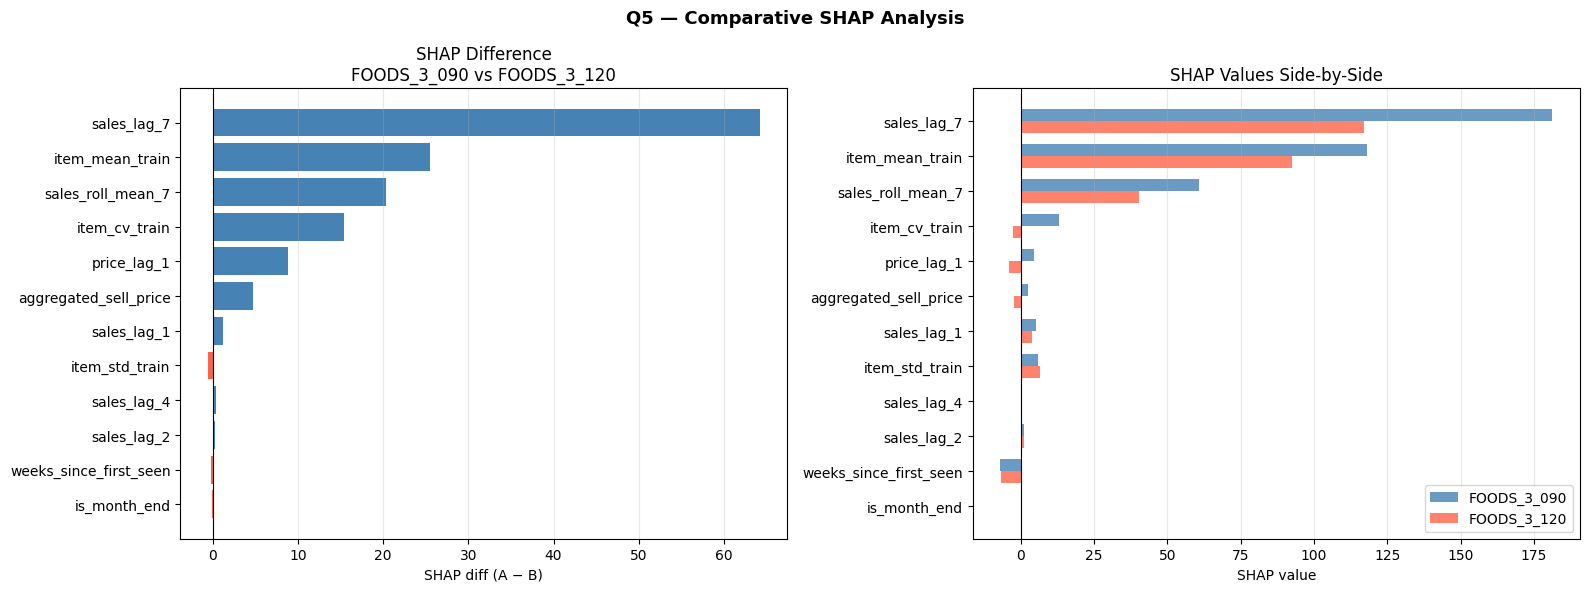

In [5]:
top_n  = 12
plot_df = diff_df.head(top_n).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: SHAP diff bar chart ---
colors = ['steelblue' if d > 0 else 'tomato' for d in plot_df['diff']]
axes[0].barh(plot_df['feature'][::-1], plot_df['diff'][::-1], color=colors[::-1])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('SHAP diff (A − B)')
axes[0].set_title(f'SHAP Difference\n{sku_a} vs {sku_b}')
axes[0].grid(axis='x', alpha=0.3)

# --- Right: side-by-side SHAP values ---
x    = np.arange(top_n)
w    = 0.35
axes[1].barh(x + w/2, plot_df['shap_a'][::-1].values, w, label=sku_a, color='steelblue', alpha=0.8)
axes[1].barh(x - w/2, plot_df['shap_b'][::-1].values, w, label=sku_b, color='tomato',    alpha=0.8)
axes[1].set_yticks(x)
axes[1].set_yticklabels(plot_df['feature'][::-1].values)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('SHAP value')
axes[1].set_title('SHAP Values Side-by-Side')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Q5 — Comparative SHAP Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6) NLG Comparative Explanation

In [6]:
text = generate_comparative_text(sku_a, sku_b, diff_df)
print(text)

=== Comparative SHAP: FOODS_3_090 vs FOODS_3_120 ===
(Aggregated over 11 rows for FOODS_3_090, 11 rows for FOODS_3_120)
Mean forecast — FOODS_3_090: 399.8 units  |  FOODS_3_120: 259.7 units  (140.1 units higher for FOODS_3_090)

Top 5 features driving the difference:
  sales_lag_7                          SHAP_A=+181.258  SHAP_B=+117.040  diff=+64.218  → pushes forecast UP for FOODS_3_090
  item_mean_train                      SHAP_A=+117.999  SHAP_B=+92.477  diff=+25.522  → pushes forecast UP for FOODS_3_090
  sales_roll_mean_7                    SHAP_A=+60.619  SHAP_B=+40.325  diff=+20.294  → pushes forecast UP for FOODS_3_090
  item_cv_train                        SHAP_A=+12.923  SHAP_B=-2.533  diff=+15.456  → pushes forecast UP for FOODS_3_090
  price_lag_1                          SHAP_A=+4.631  SHAP_B=-4.183  diff=+8.814  → pushes forecast UP for FOODS_3_090

Primary driver: 'sales_lag_7' accounts for 64.218 SHAP units more for FOODS_3_090, indicating higher demand relative to FO